# 02 — Analyze Visium Fluorescence Data

**Spatial Transcriptomics Project | 10x Genomics**

This notebook applies Squidpy image analysis to Visium fluorescence data.

**Dataset:** Mouse brain coronal section — Visium (pre-processed, pre-annotated).

**Fluorescence channels:** Channel 0 = DAPI (DNA), Channel 1 = anti-NEUN (neurons), Channel 2 = anti-GFAP (glia)

**Steps:** Load data → visualize clusters → visualize channels → segment nuclei → extract features → cluster image features → compare to gene clusters

## 1. Install Dependencies

In [1]:
!pip install squidpy anndata scanpy igraph leidenalg -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6

## 2. Import Packages & Load Data

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import squidpy as sq

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

squidpy==1.8.1


In [3]:
# Load pre-processed fluorescence dataset (downloads automatically)
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

print(adata)
print(f"Spots: {adata.n_obs} | Genes: {adata.n_vars}")

INFO     Downloading visium_fluo_image_crop.tiff from                                                              
         https://exampledata.scverse.org/squidpy/figshare/visium_fluo_image_crop.tiff                              


  0%|                                               | 0.00/317M [00:00<?, ?B/s]

INFO     Downloading visium_fluo_adata_crop.h5ad from                                                              
         https://exampledata.scverse.org/squidpy/figshare/visium_fluo_adata_crop.h5ad                              


  0%|                                              | 0.00/68.7M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 704 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Spots: 704 | Genes: 16562


## 3. Visualize Spatial Cluster Annotation

Each Visium spot is assigned a cluster based on gene expression. Here we overlay those cluster labels on the tissue image to see where each transcriptional state is located anatomically.

> **Save this plot**

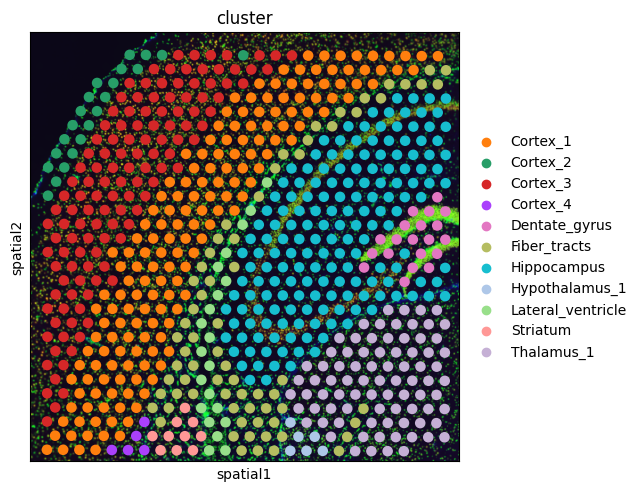

Saved: visium_fluo_cluster_spatial.png


In [4]:
sq.pl.spatial_scatter(adata, color="cluster")
plt.savefig("visium_fluo_cluster_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visium_fluo_cluster_spatial.png")

## 4. Visualize Fluorescence Image Channels

Showing each channel separately to understand tissue composition before gene analysis.

> **Save this plot**

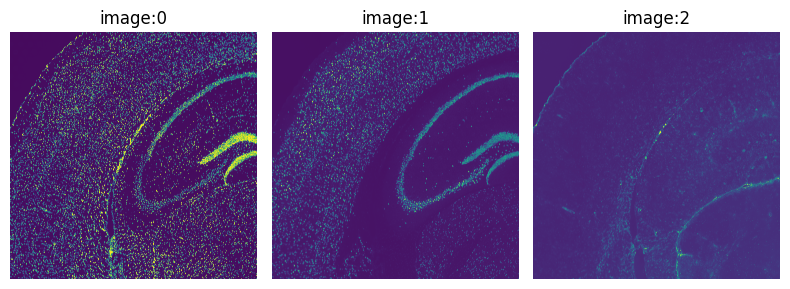

Saved: visium_fluo_channels.png


In [5]:
img.show(channelwise=True)
plt.savefig("visium_fluo_channels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visium_fluo_channels.png")

## 5. Image Segmentation (Watershed on DAPI)

We smooth the image then run watershed segmentation on the DAPI channel to identify individual nuclei. The segmented label image is stored inside the ImageContainer automatically.

> **Save this plot**

In [6]:
# Smooth image to reduce noise before segmentation
sq.im.process(img=img, layer="image", method="smooth")

# Watershed segmentation on DAPI channel (index 0)
sq.im.segment(
    img=img,
    layer="image_smooth",
    method="watershed",
    channel=0,
    chunks=1000
)

print("Segmentation complete.")
print("The segmented result is stored in img['segmented_watershed'].")

Segmentation complete.
The segmented result is stored in img['segmented_watershed'].


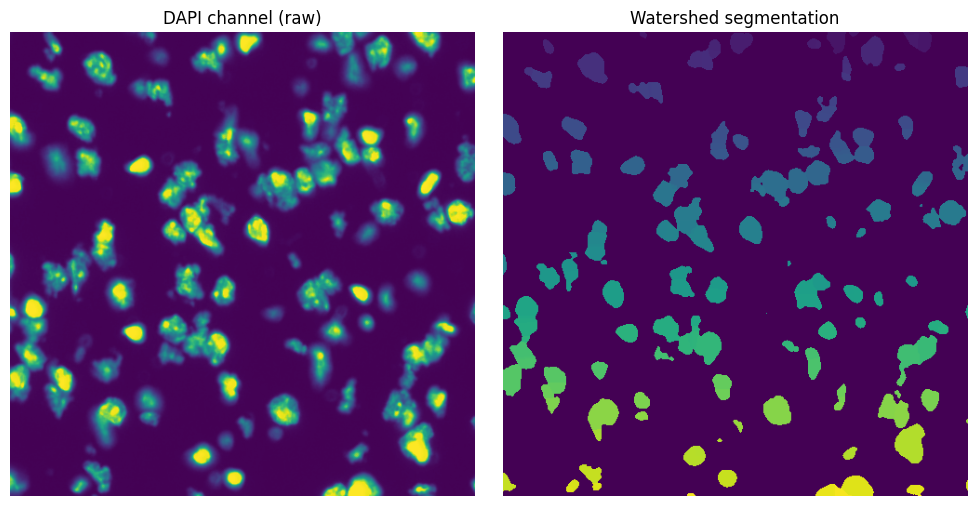

Saved: visium_fluo_segmentation.png


In [7]:
# Plot a 500x500 crop: raw DAPI vs segmented
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
img_crop = img.crop_corner(2000, 2000, size=500)

img_crop.show(layer="image", channel=0, ax=ax[0])
ax[0].set_title("DAPI channel (raw)")

img_crop.show(layer="segmented_watershed", channel=0, ax=ax[1])
ax[1].set_title("Watershed segmentation")

plt.tight_layout()
plt.savefig("visium_fluo_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visium_fluo_segmentation.png")

## 6. Extract Segmentation Features

Per-spot features derived from the segmentation:
- `segmentation_label`: approximate cell count per spot
- Channel mean intensities: proxy for cell type (NEUN = neurons, GFAP = glia)

> **Save this plot**

In [8]:
features_kwargs = {"segmentation": {"label_layer": "segmented_watershed"}}

sq.im.calculate_image_features(
    adata,
    img,
    features="segmentation",
    layer="image",
    key_added="features_segmentation",
    n_jobs=1,
    features_kwargs=features_kwargs,
)

print("Segmentation features shape:", adata.obsm["features_segmentation"].shape)

  0%|          | 0/704 [00:00<?, ?/s]

Segmentation features shape: (704, 9)


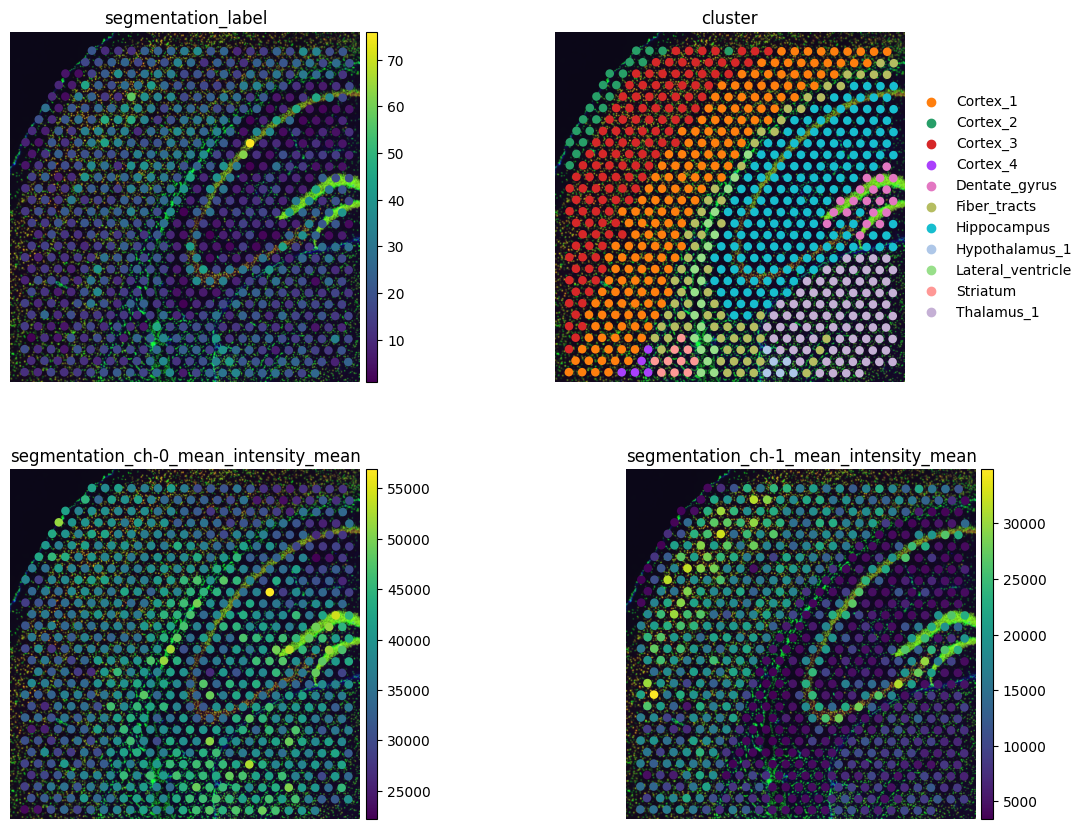

Saved: visium_fluo_segmentation_features.png


In [9]:
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "features_segmentation"),
    color=[
        "segmentation_label",
        "cluster",
        "segmentation_ch-0_mean_intensity_mean",
        "segmentation_ch-1_mean_intensity_mean",
    ],
    frameon=False,
    ncols=2,
)
plt.savefig("visium_fluo_segmentation_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visium_fluo_segmentation_features.png")

## 7. Extract Multi-Scale Image Features

Three feature types at multiple scales provide a rich description of local tissue morphology:

| Type | Captures |
|---|---|
| Summary | Mean, std, percentiles of pixel intensities |
| Histogram | Intensity value distribution |
| Texture | Spatial patterns via GLCM |

In [10]:
params = {
    "features_orig": {
        "features": ["summary", "texture", "histogram"],
        "scale": 1.0,
        "mask_circle": True,
    },
    "features_context": {
        "features": ["summary", "histogram"],
        "scale": 1.0,
    },
    "features_lowres": {
        "features": ["summary", "histogram"],
        "scale": 0.25,
    },
}

for feature_name, cur_params in params.items():
    print(f"Calculating: {feature_name}...")
    sq.im.calculate_image_features(
        adata, img, layer="image", key_added=feature_name, n_jobs=1, **cur_params
    )

# Combine into one dataframe
adata.obsm["features"] = pd.concat(
    [adata.obsm[f] for f in params.keys()], axis="columns"
)
adata.obsm["features"].columns = ad.utils.make_index_unique(
    adata.obsm["features"].columns
)

print(f"Combined features shape: {adata.obsm['features'].shape}")

Calculating: features_orig...


  0%|          | 0/704 [00:00<?, ?/s]

Calculating: features_context...


  0%|          | 0/704 [00:00<?, ?/s]

Calculating: features_lowres...


  0%|          | 0/704 [00:00<?, ?/s]

Combined features shape: (704, 195)


## 8. Cluster Image Features & Compare to Gene Clusters

Leiden clustering on the extracted image features. If image clusters and gene clusters agree, both approaches are capturing the same biology. Where they disagree, image features may provide finer detail.

> **Save this plot** — central result of this notebook.

In [11]:
def cluster_features(features: pd.DataFrame, like=None):
    """
    Leiden clustering on image features.
    Uses igraph backend (no leidenalg required).
    """
    if like is not None:
        features = features.filter(like=like)

    tmp = ad.AnnData(features)
    sc.pp.scale(tmp)
    sc.pp.pca(tmp, n_comps=min(10, features.shape[1] - 1))
    sc.pp.neighbors(tmp)
    sc.tl.leiden(tmp, flavor="igraph", n_iterations=2, directed=False)

    return tmp.obs["leiden"]

In [12]:
adata.obs["features_summary_cluster"]   = cluster_features(adata.obsm["features"], like="summary")
adata.obs["features_histogram_cluster"] = cluster_features(adata.obsm["features"], like="histogram")
adata.obs["features_texture_cluster"]   = cluster_features(adata.obsm["features"], like="texture")

print("Summary clusters:",   adata.obs["features_summary_cluster"].nunique())
print("Histogram clusters:", adata.obs["features_histogram_cluster"].nunique())
print("Texture clusters:",   adata.obs["features_texture_cluster"].nunique())

Summary clusters: 10
Histogram clusters: 13
Texture clusters: 10


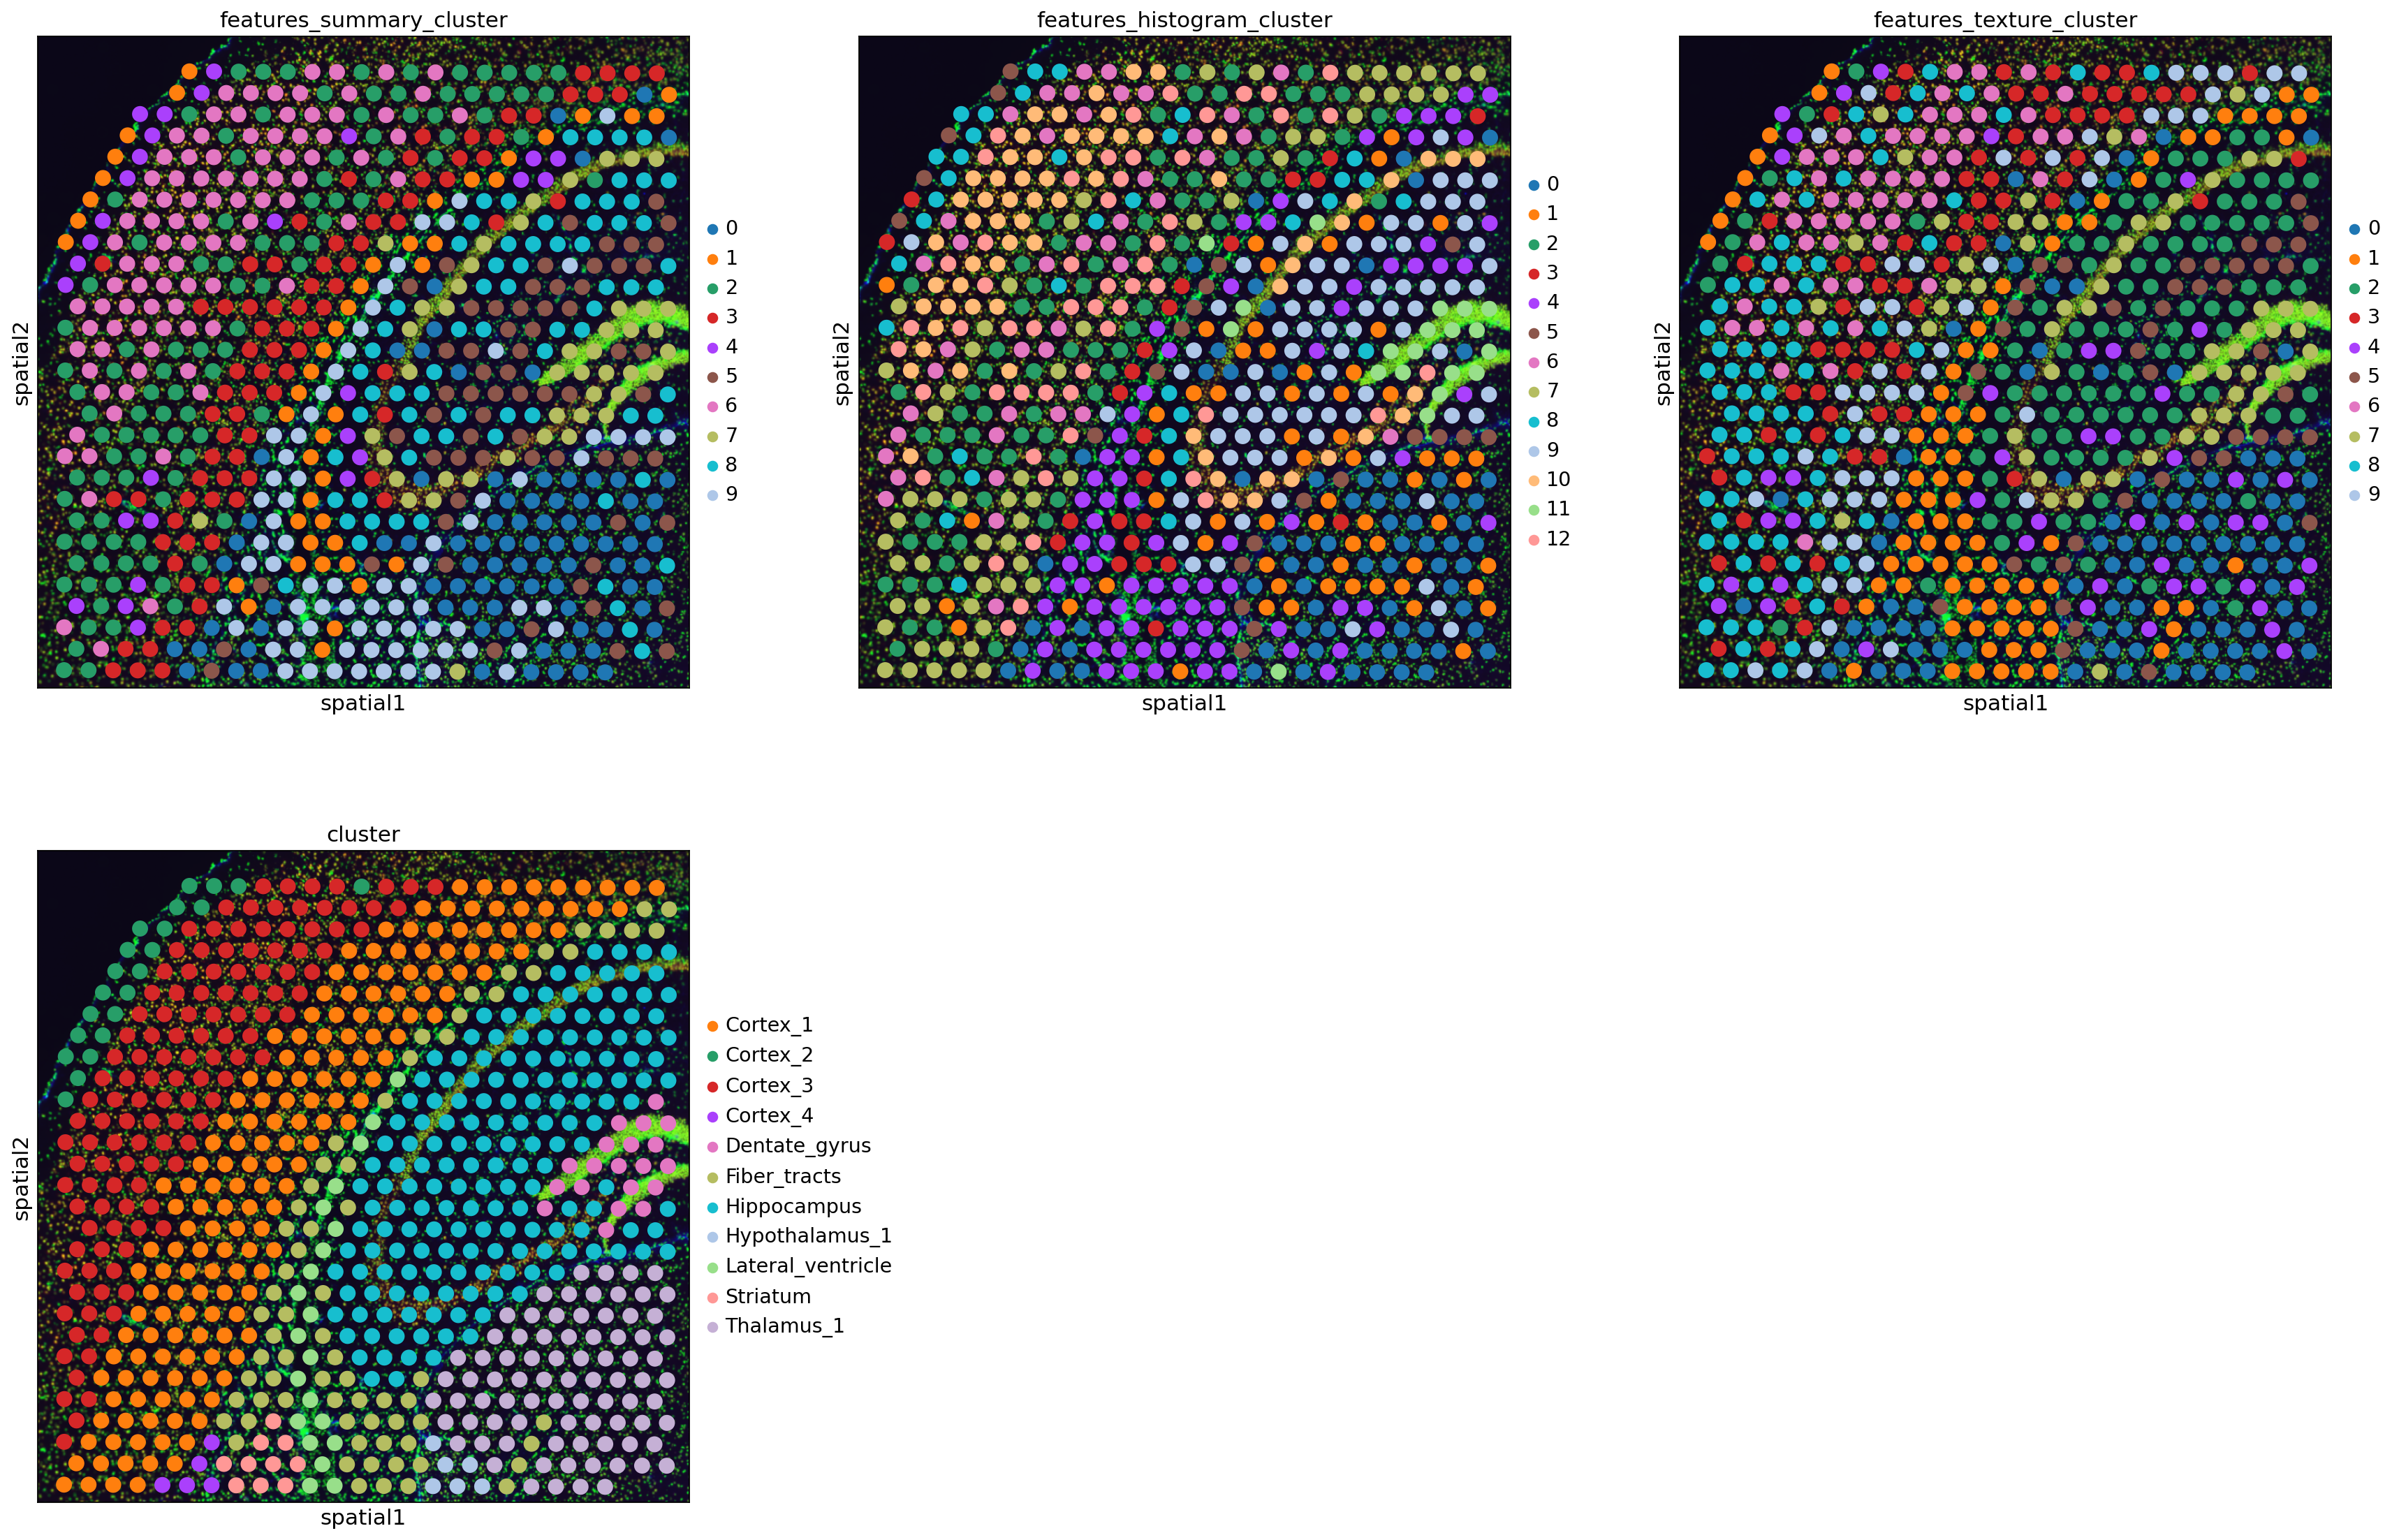

Saved: visium_fluo_image_vs_gene_clusters.png


In [13]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))

sq.pl.spatial_scatter(
    adata,
    color=[
        "features_summary_cluster",
        "features_histogram_cluster",
        "features_texture_cluster",
        "cluster",
    ],
    ncols=3,
)
plt.savefig("visium_fluo_image_vs_gene_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visium_fluo_image_vs_gene_clusters.png")

## 9. Summary

| Finding | Interpretation |
|---|---|
| Higher cell count in Hippocampal pyramidal layer | Dense packing in CA1/CA3 |
| Higher ch-1 (NEUN) in Cortex_1, Cortex_3 | More neurons in these regions |
| Higher ch-2 (GFAP) in Fiber_tracts | Glial enrichment in white matter |
| Image clusters subdivide Hippocampus more finely | Image features give higher resolution than gene clusters |

**Next:** `03_visium_hne.ipynb` — H&E staining, spatial graph analysis, ligand-receptor interactions, Moran's I.

In [14]:
adata.write_h5ad("visium_fluo_processed.h5ad")
print("Saved: visium_fluo_processed.h5ad")
print("\nFigures to download:")
for f in [
    "visium_fluo_cluster_spatial.png",
    "visium_fluo_channels.png",
    "visium_fluo_segmentation.png",
    "visium_fluo_segmentation_features.png",
    "visium_fluo_image_vs_gene_clusters.png",
]:
    print(f"  - {f}")

Saved: visium_fluo_processed.h5ad

Figures to download:
  - visium_fluo_cluster_spatial.png
  - visium_fluo_channels.png
  - visium_fluo_segmentation.png
  - visium_fluo_segmentation_features.png
  - visium_fluo_image_vs_gene_clusters.png
